# Section 3: Panel data & pseudo-experiments

### Housekeeping and Data

<font size="3">**Tarea 2**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 20/5 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. 

El archivo a utilizar es *panel_eps.csv*, que contiene un resumen de la Encuesta de Proteccion Social, en particular la caracterizacion de los individuos en distintas rondas, su situacion laboral y de salud. 

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc


Primero, importamos las distintas librerías que vamos a usar

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS
import numpy.linalg as la
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

R: Al cargar la base de datos podemos notar algunas cosas, si bien el panel no es balanceado, mantiene un buen número de respuestas, pues la mayoría ronda entre aproximadamente 16.000-17.000 observaciones. Luego eliminamos algunas variables que no tenían datos como los tipos de fondo, eliminamos valores nulos a variables que los tenían en proporciones bajas, posteriormente a variables como "children","exp","wage","sistema","cotizando" se les cambió sus valores nan por un cero, por ejemplo, si en exp había un nan, se asumió que era porque no respondió dado a no tener experiencia. Por otra parte, se sacó la ronda 1 y 6, dado que no se tenían datos para las enfermedades y para la expectativa de vida, variables de gran importancia a la hora de crear nuestros futuros modelos. Finalmente, algunas variables no fueron incluidas debido a correlaciones entre variables, exceso de valores nan o simplemente porque desde el punto de vista intuitivo no parecían ser importantes para predecir la expectativa de vida. 

folio_n20       int64
year            int64
time            int64
edad            int64
hombre        float64
edu           float64
region        float64
status        float64
kids            int64
children      float64
situation       int64
lmp             int64
exp           float64
size          float64
occupation    float64
wage          float64
hours         float64
informal      float64
selfemp       float64
publicemp     float64
sistema       float64
cotizando     float64
assets        float64
exp_sist        int64
expectancy    float64
illness       float64
cronica       float64
nocronica     float64
mental        float64
dtype: object
            folio_n20      year      time      edad    hombre       edu  \
folio_n20    1.000000  0.012877  0.014392  0.140554 -0.007245  0.246189   
year         0.012877  1.000000  0.997504  0.056241 -0.027279  0.082422   
time         0.014392  0.997504  1.000000  0.056079 -0.026982  0.081085   
edad         0.140554  0.056241  0.056079  1.000

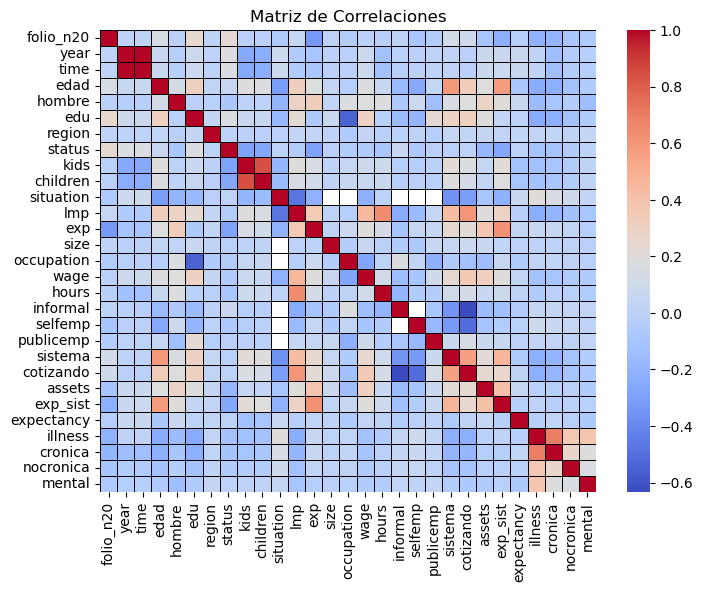

MultiIndex([(124560204870, 2),
            (124560204870, 3),
            (124560204870, 4),
            (124560204870, 5),
            (124560205935, 2),
            (124560210408, 2),
            (124560210408, 3),
            (124560210408, 5),
            (124560216585, 2),
            (124560216585, 3),
            ...
            (128133602281, 5),
            (128133606186, 5),
            (128133621806, 5),
            (128133626918, 5),
            (128133630823, 5),
            (128133653188, 5),
            (128133692735, 5),
            (128133702320, 5),
            (128133728022, 5),
            (128133731927, 5)],
           names=['folio_n20', 'time'], length=49507)


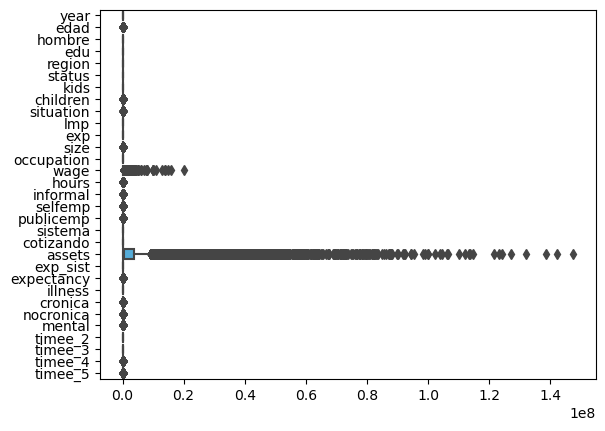

In [209]:
data=pd.read_csv('../../../data/panel_eps.csv')
datar=pd.read_csv('../../../data/panel_eps.csv')

data=data.drop("fondoa",axis=1)
data=data.drop("fondob",axis=1)
data=data.drop("fondoc",axis=1)
data=data.drop("fondod",axis=1)
data=data.drop("fondoe",axis=1)
data.dropna(subset=['status',"illness"])

print(data.dtypes)
data.drop(data[data['time'] == 1].index, inplace=True)  #eliminamos la primera ronda, dado que usaremos las enfermedades de las personas, datos los cuales no están disponibles en la primera ronda
data.loc[data["expectancy"]>=800,"expectancy"]=np.nan ##colocamos como nan los valores de expectativas irreales
data["children"].fillna(0,inplace=True) ##cambiamos los missing de children por 0, pues no tienen
data["exp"].fillna(0,inplace=True) ##cambiamos los missing de exp por 0, pues no tienen experiencia
data["wage"].fillna(0,inplace=True) ##cambiamos los missing de wage por 0, pues están inactivos
data["sistema"].fillna(0,inplace=True)
data["cotizando"].fillna(0,inplace=True)
ma=data.corr()
print(ma)
data['timee'] = data['time'].astype(object)


data=data.dropna(subset=["hombre","edu","expectancy"])
data=data.set_index(["folio_n20","time"])
data=pd.get_dummies(data)


plt.figure(figsize=(8, 6)) 
sns.heatmap(ma, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Matriz de Correlaciones')
plt.show()
sns.boxplot(data=data, orient="h")
data.describe()
print(data.index)


2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

R: Podemos encontrar que en el primer modelo las variables "lmp" y "childreen", no fueron significativas, por lo cual las sacamos, además el r cuadrado tiene un valor de 0.0291 lo cual no es bueno, pues es un modelo que explica muy poco, Por otra parte, casi todas las variables tienen una correlación negativa, a excepción de "exp", "situation", "cronica" y "edu", o sea, mientras más activo esté en el mundo laboral, más experiencia, educación y las enfermedades que posea sean de carácter crónico, más expectativa de vida tendrá.

In [ ]:

y=data['expectancy']
X=data[["status","kids","exp","situation","exp_sist","nocronica","cronica","mental","edu","timee_2","timee_3","timee_4"]]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0291
Estimator:                   PanelOLS   R-squared (Between):              0.0309
No. Observations:               49463   R-squared (Within):               0.0147
Date:               mar, may. 20 2025   R-squared (Overall):              0.0291
Time:                        11:47:12   Log-likelihood                -1.854e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      123.48
Entities:                       23740   P-value                           0.0000
Avg Obs:                       2.0835   Distribution:                F(12,49450)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             123.48
                            


3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

R: Se tiene un r cuadrado parecido, sin embargo, las únicas variables significativas son "nocronica", "cronica", "mental", "exp_sist" las cuales tienen una afectación negativa.

In [212]:
model=lmp.PanelOLS(y,X, entity_effects=True)
efi=model.fit(cov_type="robust")
print(efi)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0293
Estimator:                   PanelOLS   R-squared (Between):             -0.0271
No. Observations:               49463   R-squared (Within):               0.0293
Date:               mar, may. 20 2025   R-squared (Overall):             -0.0045
Time:                        11:56:41   Log-likelihood                -1.592e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      64.713
Entities:                       23740   P-value                           0.0000
Avg Obs:                       2.0835   Distribution:                F(12,25711)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             45.956
                            


4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

R: En este modelo observamos un r cuadrado mejor, es 0.4144, si bien aún falta, pero explica más que los demás, además nos dice que todas las variables son significativas a excepción de "edu" y las únicas que generan un efecto positivo sobre expectativa de vida son "exp", "situation" y "cronica"

In [214]:
model=lmp.RandomEffects(y,X)
eale=model.fit(cov_type="robust")
print(eale)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4144
Estimator:              RandomEffects   R-squared (Between):              0.0277
No. Observations:               49463   R-squared (Within):               0.0202
Date:               mar, may. 20 2025   R-squared (Overall):              0.0281
Time:                        12:04:14   Log-likelihood                -1.755e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2916.5
Entities:                       23740   P-value                           0.0000
Avg Obs:                       2.0835   Distribution:                F(12,49450)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             101.79
                            


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

R: Para estudiar cual sería el más adecuado vamos a realizar un test de Hausman, para ello, usamos un nivel de significancia del 0.05. Dado que nuestro valor P es menor que el nivel de significancia, rechazamos la hipótesis nula, como consecuencia de ello, nos quedamos con el modelo de efectos fijos

In [202]:
def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(efi, eale) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))
print(lmp.compare({"FE": efi, "RE": eale, "Pooled": mco}))

Hausman Test: chi-2 = 260.00589916453436, df = 14, p-value = 2.438808265349683e-47
                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 49463             49463          49463
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0294            0.4146         0.0292
R-Squared (Within)              0.0294            0.0205         0.0150
R-Squared (Between)            -0.0288            0.0278         0.0308
R-Squared (Overall)            -0.0056            0.0282         0.0292
F-statistic                     55.690            2501.1         106.18
P-value (F-stat)                0.0000            0.0


6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

R: En este modelo se obtuvo que tales variables eran significativas, por otra parte, el r cuadrado fue de 
0.4185 , lo cual es aceptable, además la mayoría de las variables agregadas para medir la heterogeneidad no observada fueron significativas (solo no lo fueron mlmp, mexp, mchildreen y mnocronica).

In [ ]:
X = data.drop(["year","edad","region","size","hombre","occupation","wage","hours","informal","selfemp","publicemp","sistema","cotizando","assets","expectancy","illness","timee_2","timee_3","timee_4"], axis=1, inplace=False)
Xm = X.groupby(by = "folio_n20").transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(data,Xm, left_index=True, right_index=True)
Y = Xc['expectancy']
X = Xc[["status","kids","lmp","exp","situation","exp_sist","nocronica","children","cronica","mental","edu","mstatus","mkids","mlmp","mexp","msituation","mexp_sist","mnocronica","mchildren","mcronica","mmental","medu","timee_2","timee_3","timee_4"]]

X=sm.add_constant(X)

model=lmp.RandomEffects(y,X)
ealec=model.fit(cov_type="robust")
print(ealec)


                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4185
Estimator:              RandomEffects   R-squared (Between):              0.0343
No. Observations:               49463   R-squared (Within):               0.0269
Date:               mar, may. 20 2025   R-squared (Overall):              0.0351
Time:                        16:11:50   Log-likelihood                -1.754e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1423.1
Entities:                       23740   P-value                           0.0000
Avg Obs:                       2.0835   Distribution:                F(25,49437)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             62.532
                            


7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

R: En el gráfico podemos notar que existe una correlación negativa dado que el pick del componente observado se da a la derecha de la heterogeneidad no observada.

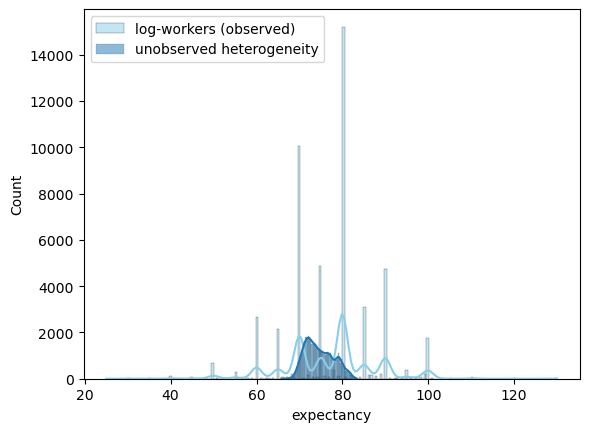

In [206]:
#status","kids","lmp","exp","situation","exp_sist","nocronica","children","cronica","mental","edu"

Xpred = X

Xpred['edu']=0
Xpred['nocronica']=0
Xpred['exp_sist']=0
Xpred['situation']=0
Xpred['exp']=0
Xpred['kids']=0
Xpred['lmp']=0
Xpred['status']=0
Xpred['children']=0 
Xpred['cronica']=0
Xpred['mental']=0
Xpred['timee_2']=0
Xpred['timee_3']=0
Xpred['timee_4']=0
yhat = ealec.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="log-workers (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend() 
plt.show()

8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

R: Haciendo la comparación tenemos que los más conveniente es quedarnos con el modelo CRE, pues los efectos fijos están sobre los efectos aleatorios según Hausman, el problema es que nuestro modelo FE cuenta con un r cuadrado demasiado bajo, pues explica menos de un 5%, mientras el CRE tiene un valor de 0.4185 en el mismo parámetro.

In [207]:
print(lmp.compare({"FE": efi, "RE": eale, "CRE": ealec}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 49463             49463             49463
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0294            0.4146            0.4185
R-Squared (Within)              0.0294            0.0205            0.0269
R-Squared (Between)            -0.0288            0.0278            0.0343
R-Squared (Overall)            -0.0056            0.0282            0.0351
F-statistic                     55.690            2501.1            1423.1
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

9. Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.